# 003 — Correção de um intervalo degradado

Agora a curva existe, mas um intervalo foi degradado. O objetivo é separar:

1. detectar medidas suspeitas;
2. decidir se devem ser mantidas, sinalizadas ou ocultadas;
3. recuperar a informação ausente;

No notebook 002 simulamos uma **curva inteira indisponível em um poço novo**.
Aqui usamos trechos confiáveis do próprio poço para calibrar a recuperação de
uma **lacuna interna**. São problemas diferentes e devem ser avaliados de modo
diferente.

In [3]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

try:
    from IPython.display import display
except ImportError:
    display = print

SEED = 42
rng = np.random.default_rng(SEED)
sns.set_theme(style="whitegrid", context="notebook")

## Configuração online

O notebook reutiliza a base preparada e, quando disponível, os parâmetros
escolhidos no notebook 002.

In [4]:
try:
    from google.colab import drive
    EM_COLAB = True
except ImportError:
    EM_COLAB = False

if EM_COLAB:
    drive.mount("/content/drive")
    PASTA_CURSO = Path("/content/drive/MyDrive/Curso_Regressao_Pocos")
else:
    PASTA_CURSO = Path.cwd()

PASTA_DADOS = PASTA_CURSO / "dados"
PASTA_SAIDAS = PASTA_CURSO / "saidas"
PASTA_DADOS.mkdir(parents=True, exist_ok=True)
PASTA_SAIDAS.mkdir(parents=True, exist_ok=True)

CAMINHO = PASTA_SAIDAS / "dados_regressao_aula.csv"
if not CAMINHO.exists():
    raise FileNotFoundError(
        "Arquivo preparado não encontrado. Execute primeiro o notebook 001 "
        "usando a mesma pasta Curso_Regressao_Pocos no Drive."
    )

print(f"Ambiente: {'Google Colab' if EM_COLAB else 'local'}")
print(f"Dados preparados: {CAMINHO}")

Mounted at /content/drive
Ambiente: Google Colab
Dados preparados: /content/drive/MyDrive/Curso_Regressao_Pocos/saidas/dados_regressao_aula.csv


## 1. Carregar a base e os parâmetros escolhidos sem usar o poço cego


In [5]:
dados = pd.read_csv(CAMINHO)
treino_externo = (
    dados.query("CONJUNTO == 'treino'").dropna(subset=["DTC"]).copy()
)
poco = (
    dados.query("CONJUNTO == 'poço cego'")
    .sort_values("DEPTH_MD")
    .reset_index(drop=True)
)

caminho_config = PASTA_SAIDAS / "config_modelos_escolhidos.json"
if caminho_config.exists():
    CONFIG = json.loads(caminho_config.read_text(encoding="utf-8"))
else:
    CONFIG = {
        "KNN": {"n_neighbors": 15, "weights": "distance", "p": 2},
        "Arvore": {"max_depth": 12, "min_samples_leaf": 20},
        "Floresta": {
            "n_estimators": 80, "max_depth": 18, "min_samples_leaf": 4
        },
        "MLP": {"hidden_layer_sizes": [40, 20], "alpha": 0.001},
    }

if poco.empty:
    raise ValueError("O conjunto do poço cego está vazio.")
print(f"Poço: {poco.WELL.iloc[0]} | {len(poco):,} linhas")
CONFIG

Poço: 15/9-13 | 18,270 linhas


{'preditores_principais': ['GR',
  'LOG_RMED',
  'LOG_RDEP',
  'RHOB',
  'NPHI',
  'CALI'],
 'usa_contexto_categorico_no_modelo_principal': False,
 'KNN': {'n_neighbors': 9, 'weights': 'uniform', 'p': 2},
 'Arvore': {'max_depth': 12, 'min_samples_leaf': 20},
 'Floresta': {'n_estimators': 50, 'max_depth': 14, 'min_samples_leaf': 5},
 'MLP': {'hidden_layer_sizes': [40, 20], 'alpha': 0.01}}

## 2. Criar uma falha controlada

Escolhemos a porção central do grupo com mais amostras de `DTC`. Dentro dela
adicionamos ruído gaussiano e picos. A referência verdadeira fica guardada
apenas para avaliar o exercício; nenhum modelo recebe `DTC` como preditor.


In [6]:
contagem_grupo = (
    poco.dropna(subset=["DTC"]).groupby("GROUP").size().sort_values(ascending=False)
)
GRUPO_INTERVALO = contagem_grupo.index[0]
profundidades_grupo = poco.loc[
    poco["GROUP"].eq(GRUPO_INTERVALO) & poco["DTC"].notna(),
    "DEPTH_MD",
]
Z_INI, Z_FIM = profundidades_grupo.quantile([0.43, 0.57])
no_intervalo = (
    poco["GROUP"].eq(GRUPO_INTERVALO)
    & poco["DEPTH_MD"].between(Z_INI, Z_FIM)
    & poco["DTC"].notna()
)

poco["DTC_CORROMPIDO"] = poco["DTC"].copy()
sigma_ruido = max(10.0, 0.65 * poco.loc[no_intervalo, "DTC"].std())
ruido = rng.normal(0, sigma_ruido, no_intervalo.sum())
picos = rng.random(no_intervalo.sum()) < 0.04
ruido[picos] += rng.choice([-35.0, 35.0], picos.sum())
poco.loc[no_intervalo, "DTC_CORROMPIDO"] += ruido

poco["DTC_COM_LACUNA"] = poco["DTC"].copy()
poco.loc[no_intervalo, "DTC_COM_LACUNA"] = np.nan

if no_intervalo.sum() < 50:
    raise ValueError("Intervalo escolhido contém poucas amostras para o exercício.")

print(f"Grupo: {GRUPO_INTERVALO}")
print(f"Intervalo: {Z_INI:.2f}–{Z_FIM:.2f} m")
print(f"Amostras degradadas: {no_intervalo.sum():,}")

Grupo: HORDALAND GP.
Intervalo: 1596.45–1744.05 m
Amostras degradadas: 971


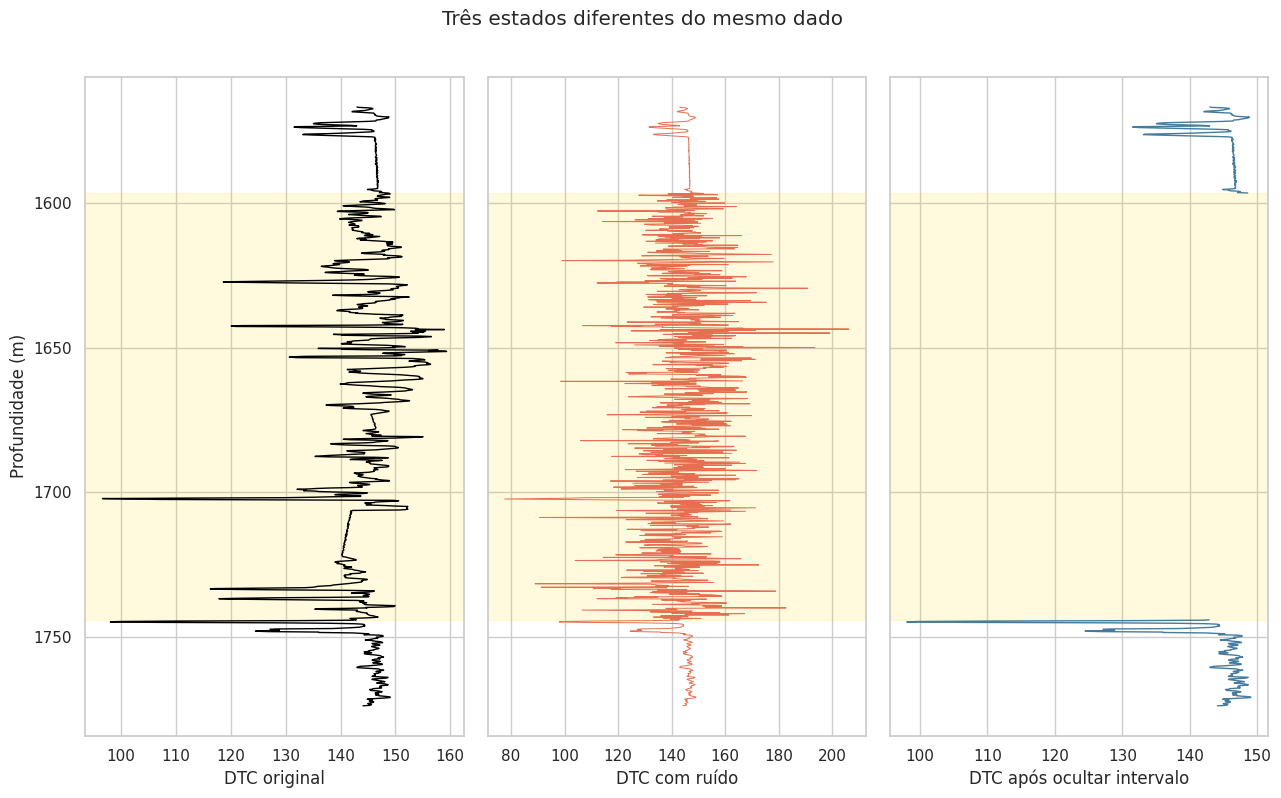

In [7]:
zoom = poco.loc[poco["DEPTH_MD"].between(Z_INI - 30, Z_FIM + 30)]
fig, axes = plt.subplots(1, 3, figsize=(13, 8), sharey=True)
axes[0].plot(zoom["DTC"], zoom["DEPTH_MD"], color="black", lw=1)
axes[0].set(xlabel="DTC original", ylabel="Profundidade (m)")
axes[1].plot(
    zoom["DTC_CORROMPIDO"], zoom["DEPTH_MD"], color="#e76f51", lw=0.7
)
axes[1].set_xlabel("DTC com ruído")
axes[2].plot(
    zoom["DTC_COM_LACUNA"], zoom["DEPTH_MD"], color="#457b9d", lw=1
)
axes[2].set_xlabel("DTC após ocultar intervalo")
for ax in axes:
    ax.axhspan(Z_INI, Z_FIM, color="gold", alpha=0.13)
axes[0].invert_yaxis()
fig.suptitle("Três estados diferentes do mesmo dado", y=0.995)
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()


## 3. Boxplot global versus contexto local

Um boxplot global pode:

- deixar passar ruído moderado que ainda cai dentro da distribuição do poço;
- marcar valores legítimos de outra unidade geológica como extremos.

Compararemos o IQR global com resíduos em relação à mediana móvel/MAD.


In [8]:
q1, q3 = poco.loc[~no_intervalo, "DTC_CORROMPIDO"].quantile([0.25, 0.75])
iqr = q3 - q1
limite_iqr = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
flag_iqr = (
    poco["DTC_CORROMPIDO"].notna()
    & ~poco["DTC_CORROMPIDO"].between(*limite_iqr)
)

mediana_movel = (
    poco["DTC_CORROMPIDO"]
    .rolling(101, center=True, min_periods=25)
    .median()
)
residuo_local = poco["DTC_CORROMPIDO"] - mediana_movel
mad_movel = (
    residuo_local.abs()
    .rolling(101, center=True, min_periods=25)
    .median()
)
z_robusto = 0.6745 * residuo_local / mad_movel.replace(0, np.nan)
flag_local = z_robusto.abs() > 4.5

linhas_deteccao = []
for nome, flag in [("IQR global", flag_iqr), ("MAD móvel", flag_local)]:
    linhas_deteccao.append(
        {
            "método": nome,
            "sinalizados no intervalo": int((flag & no_intervalo).sum()),
            "cobertura do intervalo (%)": 100 * (flag & no_intervalo).sum() / no_intervalo.sum(),
            "sinalizados fora (possíveis falsos positivos)": int(
                (flag & ~no_intervalo).sum()
            ),
        }
    )
tabela_deteccao = pd.DataFrame(linhas_deteccao)
tabela_deteccao.round(2)


,método,sinalizados no intervalo,cobertura do intervalo (%),sinalizados fora (possíveis falsos positivos)
0,IQR global,0,0.00,0
1,MAD móvel,14,1.44,516


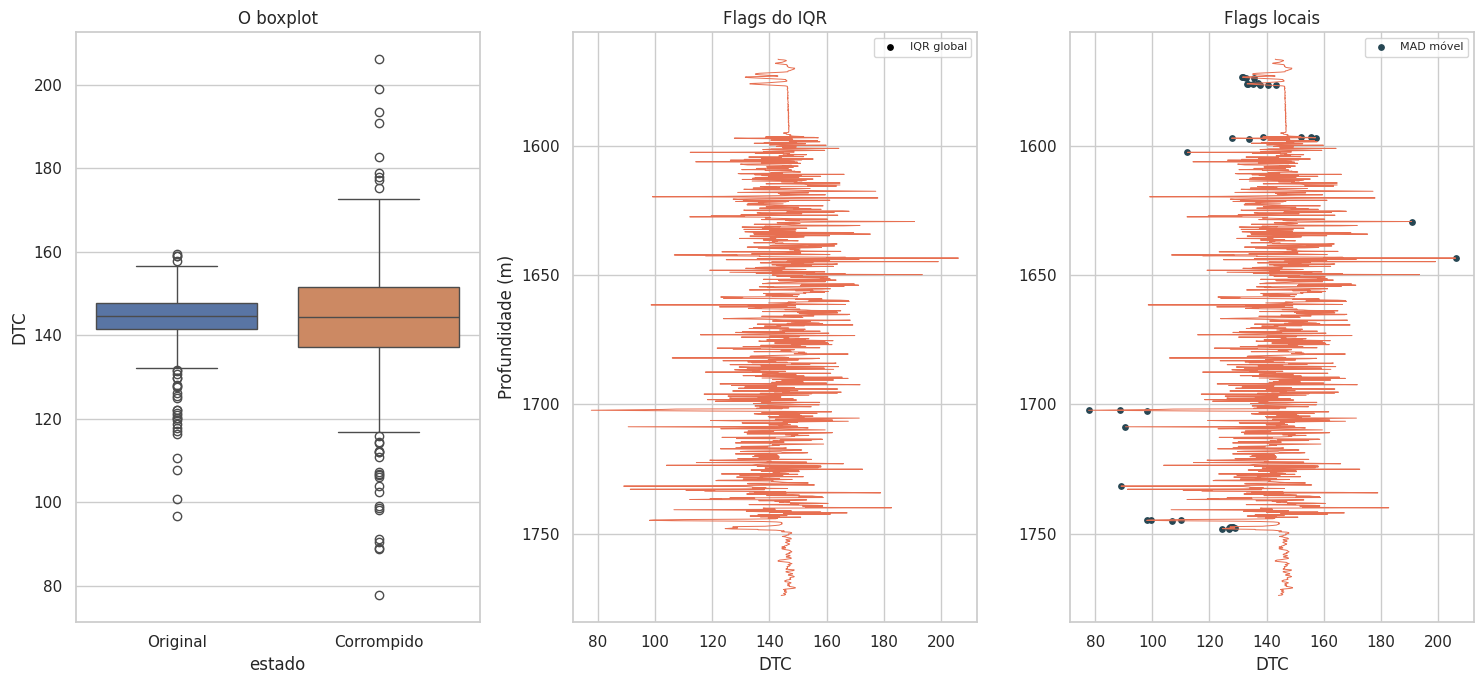

In [9]:
quadro_box = pd.DataFrame(
    {
        "Original": poco.loc[no_intervalo, "DTC"].to_numpy(),
        "Corrompido": poco.loc[no_intervalo, "DTC_CORROMPIDO"].to_numpy(),
    }
).melt(var_name="estado", value_name="DTC")

zoom_mask = poco["DEPTH_MD"].between(Z_INI - 30, Z_FIM + 30)
zoom = poco.loc[zoom_mask]
flag_iqr_zoom = flag_iqr.loc[zoom_mask]
flag_local_zoom = flag_local.loc[zoom_mask]

fig, axes = plt.subplots(1, 3, figsize=(15, 7), sharey=False)
sns.boxplot(
    data=quadro_box, x="estado", y="DTC",
    hue="estado", legend=False, ax=axes[0],
)
axes[0].set_title("O boxplot")

axes[1].plot(
    zoom["DTC_CORROMPIDO"], zoom["DEPTH_MD"], color="#e76f51", lw=0.7
)
axes[1].scatter(
    zoom.loc[flag_iqr_zoom, "DTC_CORROMPIDO"],
    zoom.loc[flag_iqr_zoom, "DEPTH_MD"],
    color="black", s=15, label="IQR global",
)
axes[1].set(xlabel="DTC", ylabel="Profundidade (m)", title="Flags do IQR")
axes[1].legend(fontsize=8)
axes[1].invert_yaxis()

axes[2].plot(
    zoom["DTC_CORROMPIDO"], zoom["DEPTH_MD"], color="#e76f51", lw=0.7
)
axes[2].scatter(
    zoom.loc[flag_local_zoom, "DTC_CORROMPIDO"],
    zoom.loc[flag_local_zoom, "DEPTH_MD"],
    color="#264653", s=15, label="MAD móvel",
)
axes[2].set(xlabel="DTC", title="Flags locais")
axes[2].legend(fontsize=8)
axes[2].invert_yaxis()
plt.tight_layout()
plt.show()


## 4. O que a exclusão faz com a profundidade?


In [10]:
passo_mediano = poco["DEPTH_MD"].diff().median()
linhas_drop_intervalo = poco.loc[~no_intervalo]
salto_maximo = linhas_drop_intervalo["DEPTH_MD"].diff().max()

consequencias = pd.Series(
    {
        "linhas apagadas": int(no_intervalo.sum()),
        "espessura sem dado (m)": float(Z_FIM - Z_INI),
        "passo mediano original (m)": float(passo_mediano),
    },
    name="consequência",
)
consequencias.round(3)


,consequência
linhas apagadas,971.000
espessura sem dado (m),147.598
passo mediano original (m),0.152


In [11]:
dtc_interpolado = (
    poco.set_index("DEPTH_MD")["DTC_COM_LACUNA"]
    .interpolate(method="index", limit_direction="both")
    .reindex(poco["DEPTH_MD"])
    .to_numpy()
)


## 5. Recuperar o intervalo com os cinco regressores


In [12]:
NUMERICAS = ["GR", "LOG_RMED", "LOG_RDEP", "RHOB", "NPHI", "CALI"]
PREDITORES = NUMERICAS.copy()


def preprocessador(escalar):
    passos_num = [("imputador", SimpleImputer(strategy="median"))]
    if escalar:
        passos_num.append(("escala", StandardScaler()))
    return ColumnTransformer(
        [("num", Pipeline(passos_num), NUMERICAS)],
        remainder="drop",
    )


def pipeline(regressor, escalar):
    return Pipeline(
        [("pre", preprocessador(escalar)), ("regressor", regressor)]
    )


def metricas(y_real, y_pred):
    y_real = np.asarray(y_real)
    y_pred = np.asarray(y_pred)
    pearson = (
        np.nan
        if np.std(y_real) == 0 or np.std(y_pred) == 0
        else np.corrcoef(y_real, y_pred)[0, 1]
    )
    return {
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "R²": r2_score(y_real, y_pred),
        "Pearson": pearson,
        "Viés": np.mean(y_pred - y_real),
    }


# Calibração local usa partes confiáveis do poço, nunca o intervalo ocultado.
local_valido = poco.loc[~no_intervalo & poco["DTC"].notna()].copy()
treino_hibrido = pd.concat(
    [treino_externo, local_valido], ignore_index=True
)

cfg_arvore = CONFIG["Arvore"]
cfg_floresta = CONFIG["Floresta"]
cfg_mlp = CONFIG["MLP"]
modelos = {
    "Linear": pipeline(LinearRegression(), escalar=True),
    "KNN": pipeline(
        KNeighborsRegressor(
            n_neighbors=int(CONFIG["KNN"]["n_neighbors"]),
            weights=CONFIG["KNN"]["weights"],
            p=int(CONFIG["KNN"]["p"]),
            n_jobs=-1,
        ),
        escalar=True,
    ),
    "Árvore": pipeline(
        DecisionTreeRegressor(
            max_depth=cfg_arvore["max_depth"],
            min_samples_leaf=int(cfg_arvore["min_samples_leaf"]),
            random_state=SEED,
        ),
        escalar=False,
    ),
    "Floresta": pipeline(
        RandomForestRegressor(
            n_estimators=int(cfg_floresta["n_estimators"]),
            max_depth=cfg_floresta["max_depth"],
            min_samples_leaf=int(cfg_floresta["min_samples_leaf"]),
            max_features=0.8,
            n_jobs=-1,
            random_state=SEED,
        ),
        escalar=False,
    ),
    "MLP": pipeline(
        MLPRegressor(
            hidden_layer_sizes=tuple(cfg_mlp["hidden_layer_sizes"]),
            alpha=float(cfg_mlp["alpha"]),
            activation="relu",
            learning_rate_init=0.001,
            max_iter=180,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=12,
            random_state=SEED,
        ),
        escalar=True,
    ),
}

y_intervalo = poco.loc[no_intervalo, "DTC"]
previsoes_intervalo = {}
resultados = [
    {
        "método": "Curva corrompida",
        **metricas(y_intervalo, poco.loc[no_intervalo, "DTC_CORROMPIDO"]),
    },
    {
        "método": "Interpolação em profundidade",
        **metricas(y_intervalo, dtc_interpolado[no_intervalo.to_numpy()]),
    },
]

for nome, modelo in modelos.items():
    modelo.fit(treino_hibrido[PREDITORES], treino_hibrido["DTC"])
    pred = modelo.predict(poco.loc[no_intervalo, PREDITORES])
    previsoes_intervalo[nome] = pred
    resultados.append({"método": nome, **metricas(y_intervalo, pred)})

comparacao = (
    pd.DataFrame(resultados).sort_values("MAE").reset_index(drop=True)
)
comparacao.round(3)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (180) reached and the optimization hasn't converged yet.
  warnings.warn(


,método,MAE,RMSE,R²,Pearson,Viés
0,Interpolação em profundidade,3.984,5.987,0.020,0.263,1.340
1,Floresta,4.277,5.264,0.242,0.574,1.305
2,MLP,4.365,5.532,0.163,0.553,1.885
3,Árvore,4.829,6.164,-0.039,0.478,1.607
4,KNN,5.111,7.070,-0.367,0.463,-0.159
5,Linear,5.977,7.102,-0.379,0.581,-5.118
6,Curva corrompida,8.549,11.489,-2.609,0.465,-0.169


**Atenção ao R² em intervalos curtos:** quando o `DTC` verdadeiro varia pouco,
pequenos desvios podem gerar R² negativo mesmo com MAE melhor. Examine MAE,
viés, resíduos, continuidade e coerência geológica em conjunto.


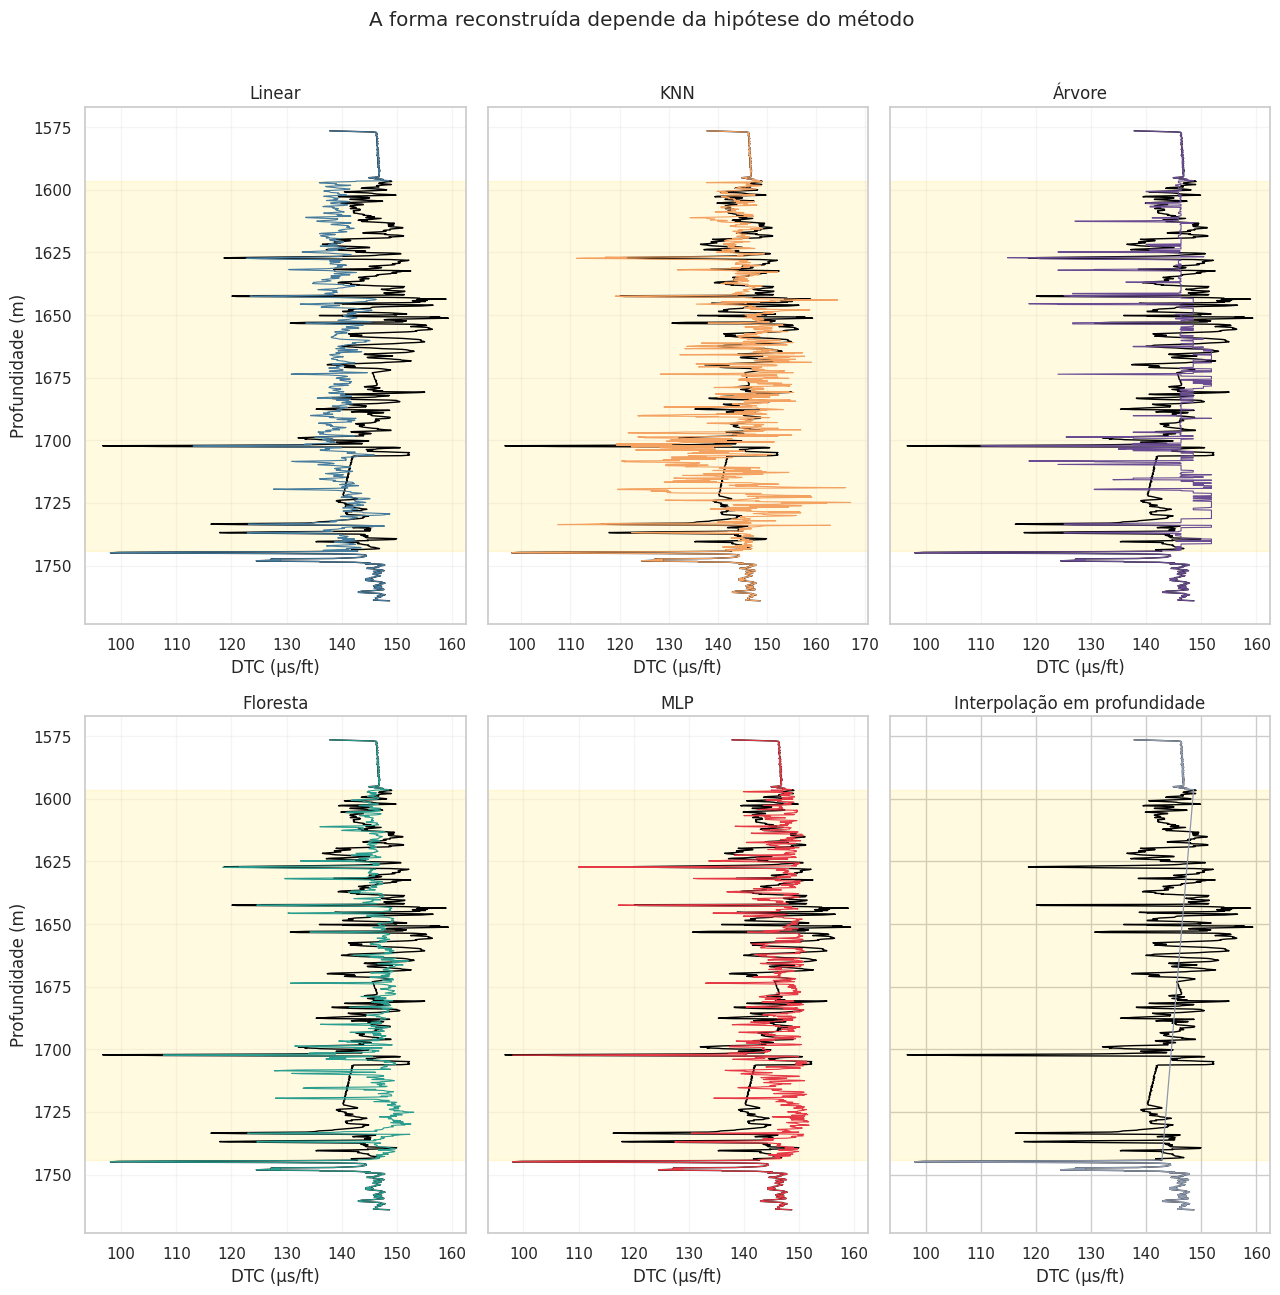

In [13]:
cores = {
    "Linear": "#457b9d",
    "KNN": "#f4a261",
    "Árvore": "#6a4c93",
    "Floresta": "#2a9d8f",
    "MLP": "#e63946",
}
zoom_mask = poco["DEPTH_MD"].between(Z_INI - 20, Z_FIM + 20)
zoom = poco.loc[zoom_mask]

fig, axes = plt.subplots(2, 3, figsize=(13, 13), sharey=True)
for ax, (nome, pred) in zip(axes.flat, previsoes_intervalo.items()):
    curva = poco["DTC"].copy()
    curva.loc[no_intervalo] = pred
    ax.plot(zoom["DTC"], zoom["DEPTH_MD"], color="black", lw=1, label="Referência")
    ax.plot(
        curva.loc[zoom_mask], zoom["DEPTH_MD"],
        color=cores[nome], lw=0.8, label=nome,
    )
    ax.axhspan(Z_INI, Z_FIM, color="gold", alpha=0.12)
    ax.set(title=nome, xlabel="DTC (µs/ft)")
    ax.grid(alpha=0.2)

curva_interpolada = poco["DTC"].copy()
curva_interpolada.loc[no_intervalo] = dtc_interpolado[no_intervalo.to_numpy()]
axes.flat[5].plot(
    zoom["DTC"], zoom["DEPTH_MD"], color="black", lw=1, label="Referência"
)
axes.flat[5].plot(
    curva_interpolada.loc[zoom_mask], zoom["DEPTH_MD"],
    color="#8d99ae", lw=0.9, label="Interpolação",
)
axes.flat[5].axhspan(Z_INI, Z_FIM, color="gold", alpha=0.12)
axes.flat[5].set(title="Interpolação em profundidade", xlabel="DTC (µs/ft)")
axes[0, 0].set_ylabel("Profundidade (m)")
axes[1, 0].set_ylabel("Profundidade (m)")
axes[0, 0].invert_yaxis()
fig.suptitle("A forma reconstruída depende da hipótese do método", y=0.995)
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()


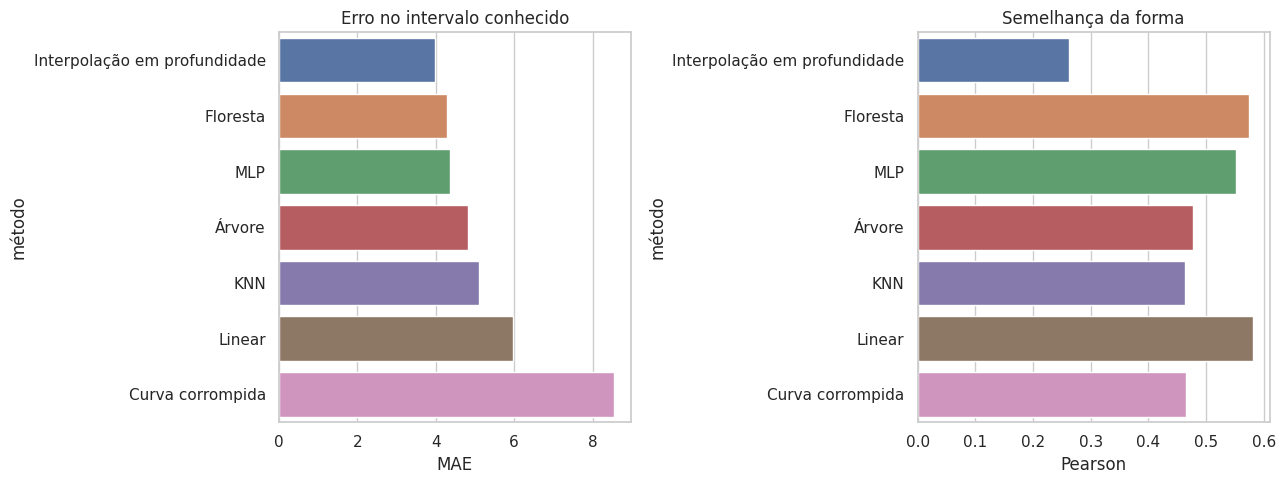

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(
    data=comparacao,
    x="MAE",
    y="método",
    hue="método",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Erro no intervalo conhecido")
sns.barplot(
    data=comparacao,
    x="Pearson",
    y="método",
    hue="método",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Semelhança da forma")
plt.tight_layout()
plt.show()


## 6. Incerteza ilustrativa com as árvores da floresta


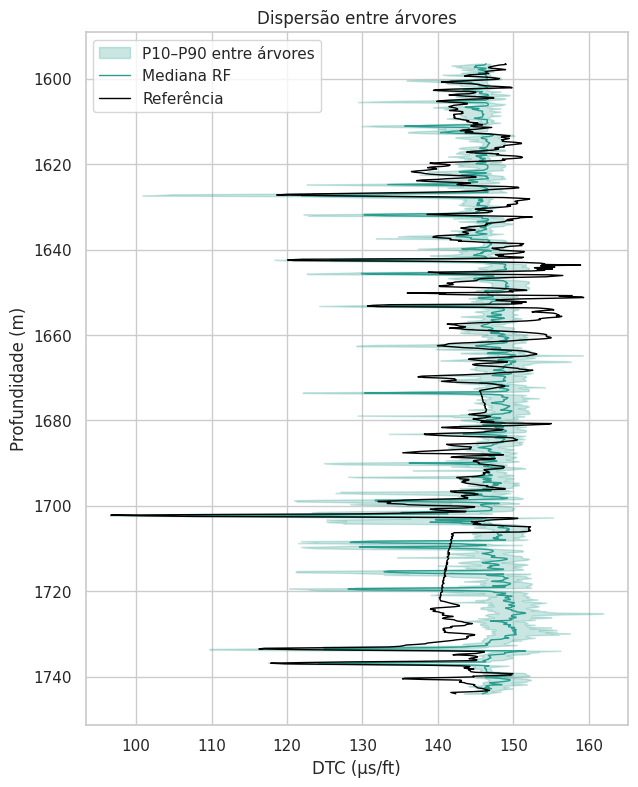

In [15]:
modelo_rf = modelos["Floresta"]
X_intervalo_rf = modelo_rf.named_steps["pre"].transform(
    poco.loc[no_intervalo, PREDITORES]
)
pred_arvores = np.vstack(
    [
        arvore.predict(X_intervalo_rf)
        for arvore in modelo_rf.named_steps["regressor"].estimators_
    ]
)
rf_p10, rf_mediana, rf_p90 = np.quantile(
    pred_arvores, [0.10, 0.50, 0.90], axis=0
)
z_intervalo = poco.loc[no_intervalo, "DEPTH_MD"].to_numpy()

fig, ax = plt.subplots(figsize=(7, 9))
ax.fill_betweenx(
    z_intervalo, rf_p10, rf_p90,
    color="#2a9d8f", alpha=0.25, label="P10–P90 entre árvores",
)
ax.plot(rf_mediana, z_intervalo, color="#2a9d8f", lw=1, label="Mediana RF")
ax.plot(
    poco.loc[no_intervalo, "DTC"], z_intervalo,
    color="black", lw=1, label="Referência",
)
ax.invert_yaxis()
ax.set(xlabel="DTC (µs/ft)", ylabel="Profundidade (m)")
ax.legend()
ax.set_title("Dispersão entre árvores")
plt.show()


## 7. Reconstruir e exportar


In [16]:
MODELO_REGRESSAO = (
    comparacao.loc[
        ~comparacao["método"].isin(
            ["Curva corrompida", "Interpolação em profundidade"]
        )
    ]
    .iloc[0]["método"]
)
MELHOR_METODO_GERAL = comparacao.iloc[0]["método"]

if MELHOR_METODO_GERAL == "Interpolação em profundidade":
    pred_melhor_geral = dtc_interpolado[no_intervalo.to_numpy()]
elif MELHOR_METODO_GERAL == "Curva corrompida":
    pred_melhor_geral = poco.loc[
        no_intervalo, "DTC_CORROMPIDO"
    ].to_numpy()
else:
    pred_melhor_geral = previsoes_intervalo[MELHOR_METODO_GERAL]

poco["DTC_PREDITO_INTERVALO"] = np.nan
poco.loc[no_intervalo, "DTC_PREDITO_INTERVALO"] = previsoes_intervalo[
    MODELO_REGRESSAO
]
poco["DTC_CURVA_FINAL"] = poco["DTC"].copy()
poco.loc[no_intervalo, "DTC_CURVA_FINAL"] = previsoes_intervalo[
    MODELO_REGRESSAO
]
poco["DTC_CURVA_FINAL_MELHOR_METODO"] = poco["DTC"].copy()
poco.loc[
    no_intervalo, "DTC_CURVA_FINAL_MELHOR_METODO"
] = pred_melhor_geral

saida = poco[
    ["WELL", "DEPTH_MD", "GROUP", "LITHOLOGY", "DTC"]
].copy()
saida = saida.rename(columns={"DTC": "DTC_ORIGINAL_REFERENCIA"})
saida["DTC_ENTRADA_COM_LACUNA"] = poco["DTC_COM_LACUNA"]
saida["DTC_ENTRADA_CORROMPIDA"] = poco["DTC_CORROMPIDO"]
saida["DTC_RECUPERADO"] = poco["DTC_PREDITO_INTERVALO"]
saida["DTC_CURVA_FINAL"] = poco["DTC_CURVA_FINAL"]
saida["DTC_CURVA_FINAL_MELHOR_METODO"] = poco[
    "DTC_CURVA_FINAL_MELHOR_METODO"
]
saida["FLAG_DTC_SINTETICO"] = no_intervalo.to_numpy()
saida["MODELO_REGRESSAO"] = np.where(
    no_intervalo, MODELO_REGRESSAO, "medido/original"
)
saida["MELHOR_METODO_BACKTEST"] = np.where(
    no_intervalo, MELHOR_METODO_GERAL, "medido/original"
)

nome_poco = poco.WELL.iloc[0].replace("/", "-").replace(" ", "_")
caminho_saida = PASTA_SAIDAS / f"DTC_{nome_poco}_intervalo_recuperado.csv"
caminho_metricas = PASTA_SAIDAS / "metricas_intervalo_recuperado.csv"
saida.to_csv(caminho_saida, index=False, float_format="%.6f")
comparacao.to_csv(caminho_metricas, index=False, float_format="%.6f")

assert saida.loc[
    saida["FLAG_DTC_SINTETICO"], "DTC_RECUPERADO"
].notna().all()
assert saida.loc[
    ~saida["FLAG_DTC_SINTETICO"], "DTC_RECUPERADO"
].isna().all()
print(f"Melhor regressão: {MODELO_REGRESSAO}")
print(f"Melhor método geral no backtest: {MELHOR_METODO_GERAL}")
print(f"Resultado rastreável: {caminho_saida}")

Melhor regressão: Floresta
Melhor método geral no backtest: Interpolação em profundidade
Resultado rastreável: /content/drive/MyDrive/Curso_Regressao_Pocos/saidas/DTC_15-9-13_intervalo_recuperado.csv
